In [ ]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


Upload TWO stereo images...


Saving WhatsApp Image 2026-04-09 at 11.45.21 AM (1).jpeg to WhatsApp Image 2026-04-09 at 11.45.21 AM (1).jpeg
Saving WhatsApp Image 2026-04-09 at 11.45.20 AM (1).jpeg to WhatsApp Image 2026-04-09 at 11.45.20 AM (1).jpeg


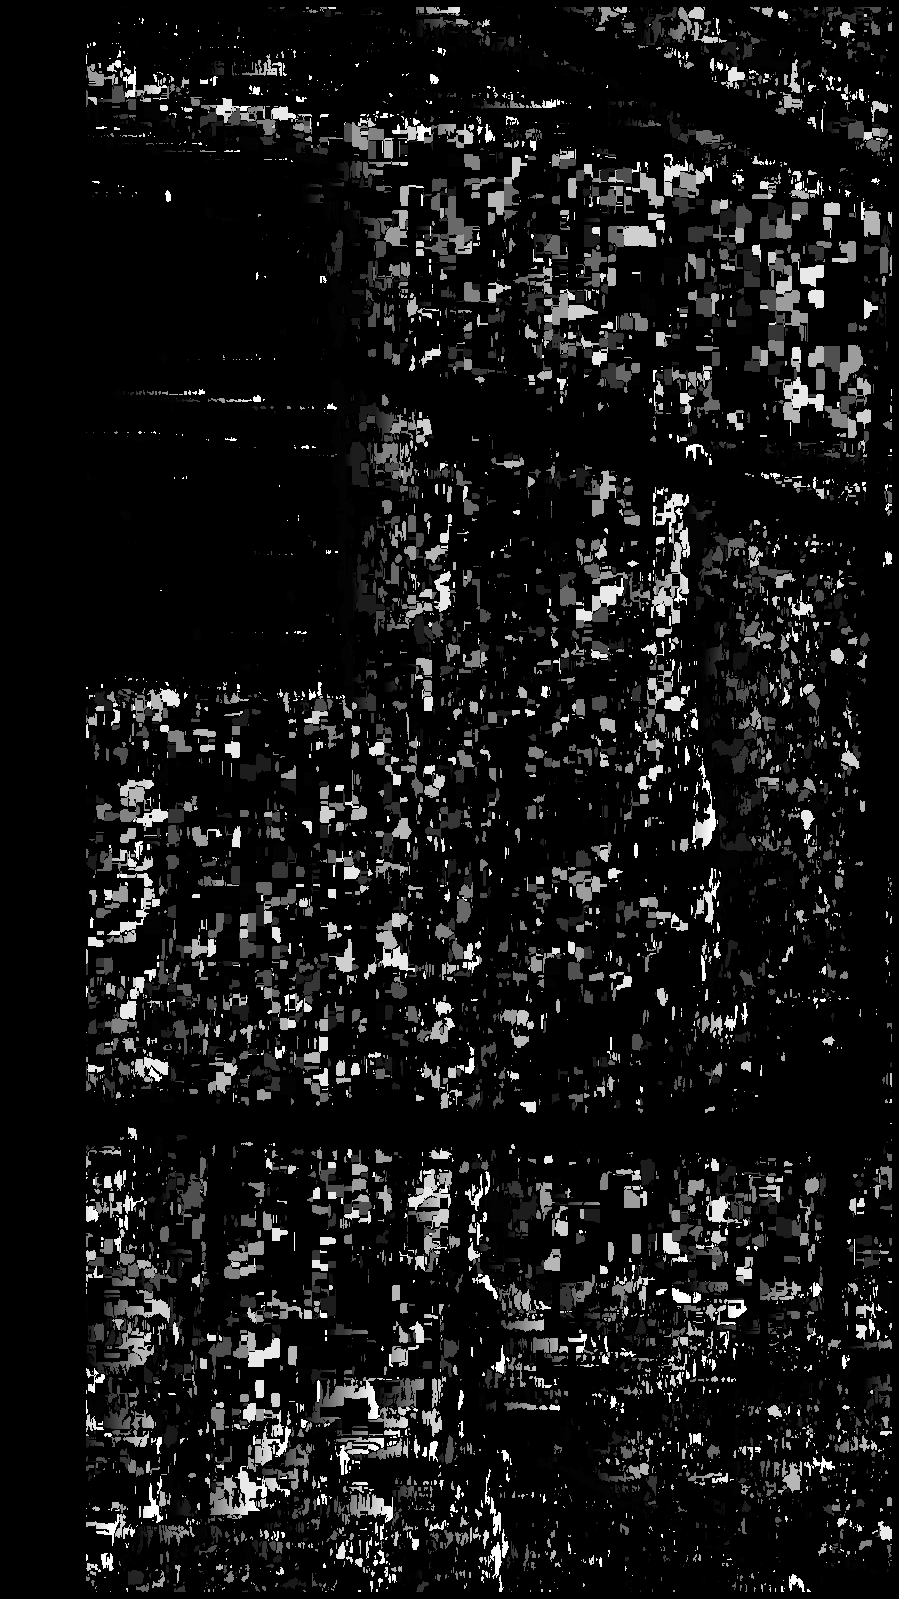

✅ Depth map generated (images resized automatically)


In [1]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

print("Upload TWO stereo images...")
uploaded = files.upload()

# Get filenames
file_names = list(uploaded.keys())
if len(file_names) < 2:
    print("Need 2 images, but got:", len(file_names))
    raise SystemExit

left_name = file_names[0]
right_name = file_names[1]

left_img = cv2.imread(left_name, cv2.IMREAD_GRAYSCALE)
right_img = cv2.imread(right_name, cv2.IMREAD_GRAYSCALE)

if left_img is None or right_img is None:
    print("Error loading images")
    raise SystemExit

# -----------------------------
# Resize images to same size
# -----------------------------
h, w = left_img.shape
right_img = cv2.resize(right_img, (w, h))

# -----------------------------
# Stereo BM
# -----------------------------
stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=15)

disparity = stereo.compute(left_img, right_img)

# Normalize for display
depth_map = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
depth_map = depth_map.astype(np.uint8)

cv2_imshow(depth_map)
print("✅ Depth map generated (images resized automatically)")